In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


In [4]:
train_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,0.0,1.0,24.80,2.5,0.0
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,0.0,1.0,31.55,2.5,0.0
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,0.0,1.0,24.84,2.5,0.0
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,0.0,1.0,13.45,2.5,0.0
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,0.0,1.0,29.88,2.5,0.0


In [5]:
test_df.head()

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee
0,0,1,2023-06-30 20:48:10,2023-06-30 21:49:13,1.0,1.57,1.0,N,161,92,Cash,1.0,2.486622,0.0,1.0,2.5,0.0
1,1,0,2023-06-29 10:58:03,2023-06-29 12:00:43,1.0,2.80,1.0,N,145,209,Credit Card,2.5,6.627894,0.0,1.0,2.5,0.0
2,2,1,2023-06-30 13:57:25,2023-06-30 13:41:32,1.0,2.53,1.0,N,221,187,Credit Card,0.0,7.958300,0.0,1.0,2.5,0.0
3,3,1,2023-06-30 03:20:58,2023-06-30 04:04:18,1.0,2.51,1.0,N,100,142,Cash,1.0,4.815220,0.0,1.0,2.5,0.0
4,4,1,2023-06-29 11:27:35,2023-06-29 10:48:37,1.0,0.36,1.0,N,199,257,Credit Card,0.0,5.788000,0.0,1.0,2.5,0.0



## Identifying Data types

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

**The training data contains 15 features and 1 target varible. Out of which tpep_pickup_datetime,tpep_dropoff_datetime,store_and_fwd_flag,payment_type are categorical variables and rest are numerical variable and total_amount is the target variable**

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1500 non-null   int64  
 1   VendorID               1500 non-null   int64  
 2   tpep_pickup_datetime   1500 non-null   object 
 3   tpep_dropoff_datetime  1500 non-null   object 
 4   passenger_count        1445 non-null   float64
 5   trip_distance          1500 non-null   float64
 6   RatecodeID             1445 non-null   float64
 7   store_and_fwd_flag     1445 non-null   object 
 8   PULocationID           1500 non-null   int64  
 9   DOLocationID           1500 non-null   int64  
 10  payment_type           1500 non-null   object 
 11  extra                  1500 non-null   float64
 12  tip_amount             1500 non-null   float64
 13  tolls_amount           1500 non-null   float64
 14  improvement_surcharge  1500 non-null   float64
 15  cong

## Descriptive Statistics of Numerical Columns

In [9]:
train_df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,10000.000000,9634.000000,10000.000000,9634.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9634.000000,9634.000000
mean,0.729100,1.357276,3.679527,1.450695,132.710800,132.33240,1.940950,6.094658,0.664425,0.979490,29.740157,2.238426,0.161122
std,0.444672,0.883676,4.905798,5.988978,75.789597,75.95944,1.945885,4.438894,2.441070,0.200076,26.256398,0.834189,0.512859
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,-7.500000,0.000713,-26.550000,-1.000000,-129.300000,-2.500000,-1.750000
25%,0.000000,1.000000,1.070000,1.000000,67.000000,68.00000,0.000000,3.466789,0.000000,1.000000,16.300000,2.500000,0.000000
50%,1.000000,1.000000,1.820000,1.000000,133.000000,132.00000,1.750000,5.208233,0.000000,1.000000,21.360000,2.500000,0.000000
75%,1.000000,1.000000,3.630000,1.000000,198.000000,199.00000,2.500000,7.455228,0.000000,1.000000,31.800000,2.500000,0.000000
max,2.000000,6.000000,71.940000,99.000000,264.000000,264.00000,11.750000,84.032617,32.050000,1.000000,551.000000,2.500000,1.750000



* passenger_count cannot be 0
* trip_distance cannot be 0 and there is so much deviation.
* extra field cannot be negative.
* tip_amount is so high at some point.
* tolls_amount can't be negative.
* total_amount can't be negative. Huge gap between min max might have outliers
* congestion_surcharge can't be negative
* Airport fee also can't be negative


## Identifying and Handling Missing values


In [10]:
train_df.isna().sum()

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

**There are 366 null values in passenger_count,RatecodeID ,store_and_fwd_flag,congestion_surcharge,Airport_fee in each of this column**

In [11]:
test_df.isna().sum()

id                        0
VendorID                  0
tpep_pickup_datetime      0
tpep_dropoff_datetime     0
passenger_count          55
trip_distance             0
RatecodeID               55
store_and_fwd_flag       55
PULocationID              0
DOLocationID              0
payment_type              0
extra                     0
tip_amount                0
tolls_amount              0
improvement_surcharge     0
congestion_surcharge     55
Airport_fee              55
dtype: int64

**There are 55 null values in passenger_count,RatecodeID ,store_and_fwd_flag,congestion_surcharge,Airport_fee in each of this column**

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [13]:
num_cols = [
    "passenger_count",
    "congestion_surcharge",
    "Airport_fee"
]

cat_cols = [
    "RatecodeID",
    "store_and_fwd_flag"
]

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_imputer", SimpleImputer(strategy="median"), num_cols),
        ("cat_imputer", SimpleImputer(strategy="most_frequent"), cat_cols)
    ],
)
all_cols = num_cols + cat_cols


In [15]:
train_imputed = preprocessor.fit_transform(train_df)

train_imputed = pd.DataFrame(
    train_imputed,
    columns=all_cols,
    index = train_df.index
)
train_df[all_cols] = train_imputed

test_imputed = preprocessor.transform(test_df)

test_imputed = pd.DataFrame(
    test_imputed,
    columns=all_cols,
    index=test_df.index
)

test_df[all_cols] = test_imputed
train_df.shape

(10000, 17)

In [16]:
train_df.isna().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
extra                    0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        10000 non-null  object 
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             10000 non-null  object 
 6   store_and_fwd_flag     10000 non-null  object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

In [18]:
test_df.isna().sum()

id                       0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
extra                    0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
congestion_surcharge     0
Airport_fee              0
dtype: int64

**Now Both the train and test data null value has been imputed**

## Identifying and Handling the Duplicates

In [19]:
train_df.duplicated().sum()


np.int64(0)

**As there is no duplicates in the train dataset.We don't need to do any work for duplicates in this data**

## Identifying and handling Outliers

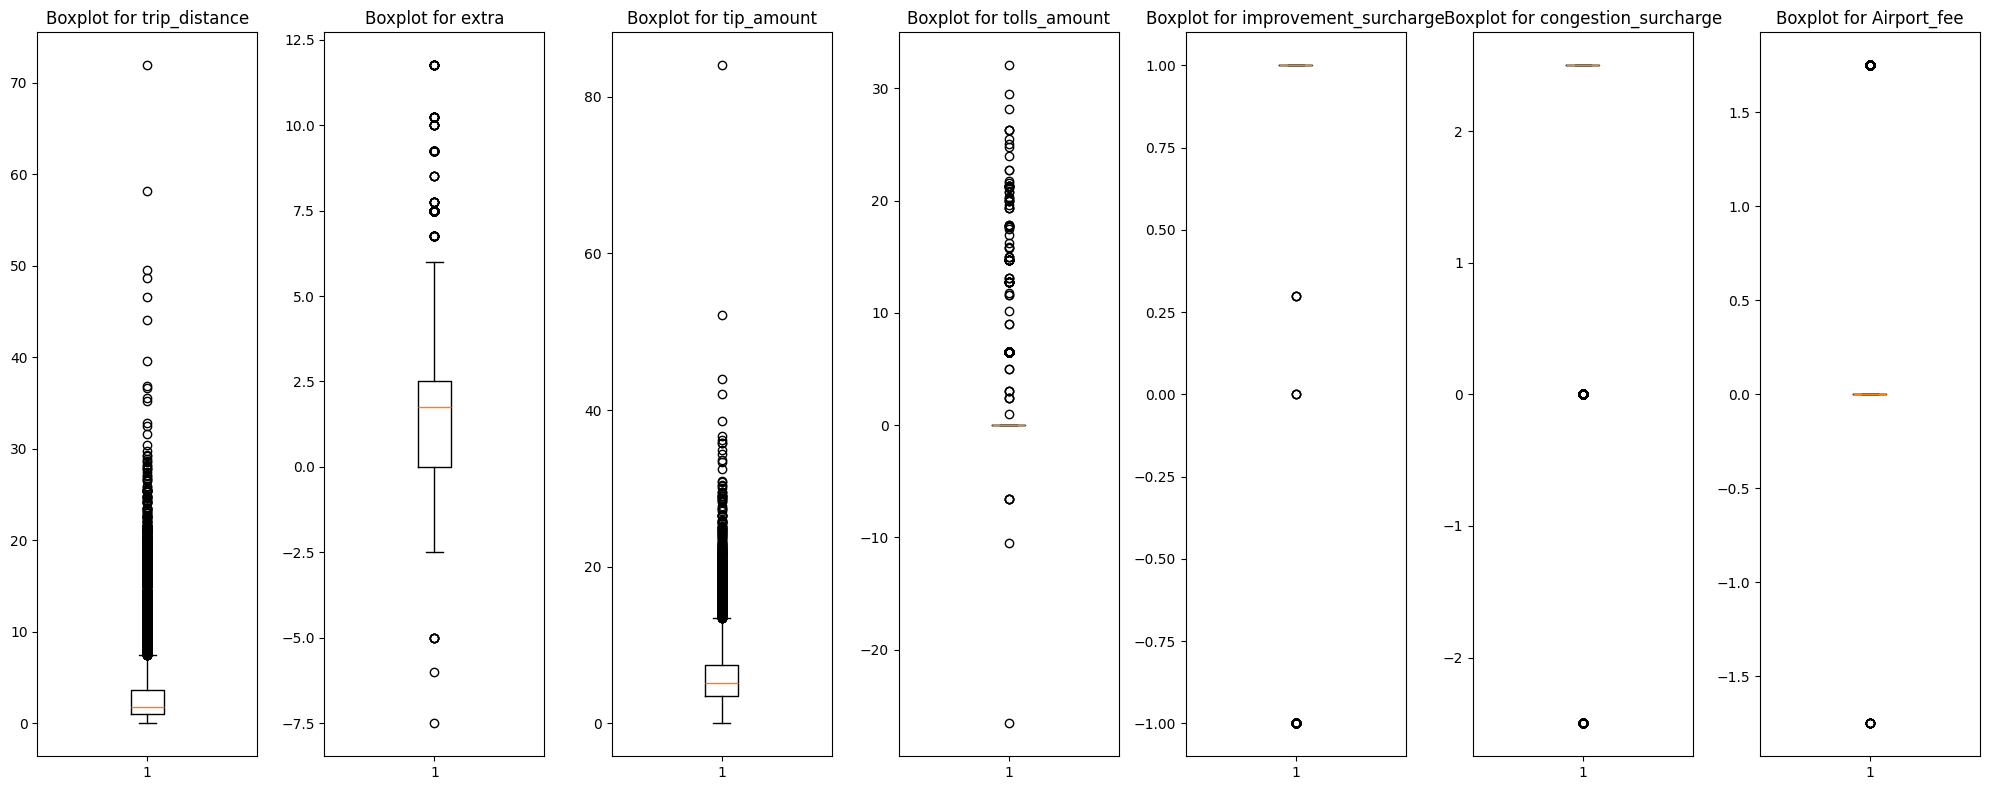

In [20]:
import matplotlib.pyplot as plt

columns = ['trip_distance', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge','Airport_fee']

fig, axis = plt.subplots(1,len(columns),figsize=(20,8))
axis = axis.flatten()

for i in range(len(columns)):
    axis[i].boxplot(train_df[columns[i]].dropna())
    axis[i].set_title(f'Boxplot for {columns[i]}')

plt.tight_layout()
plt.show()

**In the above analysis In the trip_distance, tip_amount and tolls_amount there is so much outliers but we keep all of them as we impute them with  median as it will get compacted within the range of median and this much amount of data can't be removed. So we keep as it is so that model learn  the pattern more easily and for rest there is very few outlier which won't affect the data so much so we keep that as it is.**

In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        10000 non-null  object 
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             10000 non-null  object 
 6   store_and_fwd_flag     10000 non-null  object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

## Visualization1 :- Histogram of Total amount with their frequency

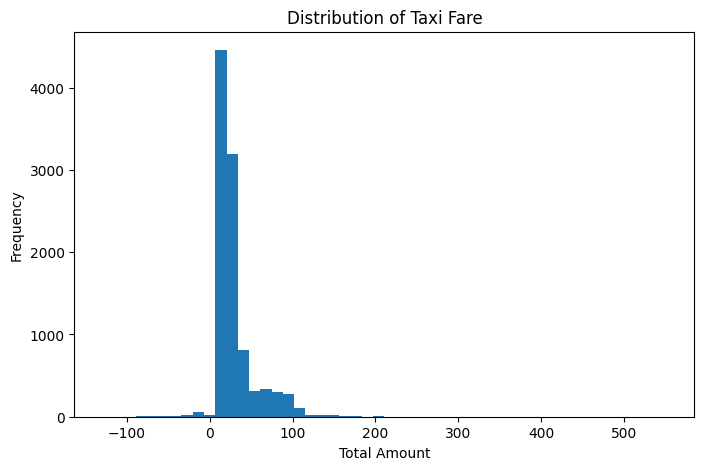

In [22]:
plt.figure(figsize=(8,5))

plt.hist(train_df["total_amount"], bins=50)

plt.title("Distribution of Taxi Fare")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

**The histogram states that Total Price amount lie between mostly in 0 to 100 range.It states that most of the data is inside this region and states that maximum data is between this region rest few are the outliers for this data.**


## Visualization2 :- Average Fare by Passenger Count

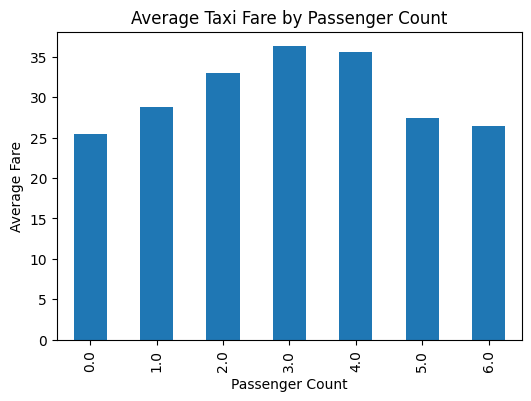

In [23]:
avg_fare_passenger = train_df.groupby("passenger_count")["total_amount"].mean()

plt.figure(figsize=(6,4))
avg_fare_passenger.plot(kind="bar")

plt.title("Average Taxi Fare by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Average Fare")

plt.show()

**Fare generally increases steadily as the passenger count increases.But drastically decreases for count 6. It might happen because of small data for the passenger count having 6 value.**

## Visualization3 :- Average Fare by distance

/tmp/ipykernel_55/4055125095.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_fare = train_df.groupby("distance_bins")["total_amount"].mean()


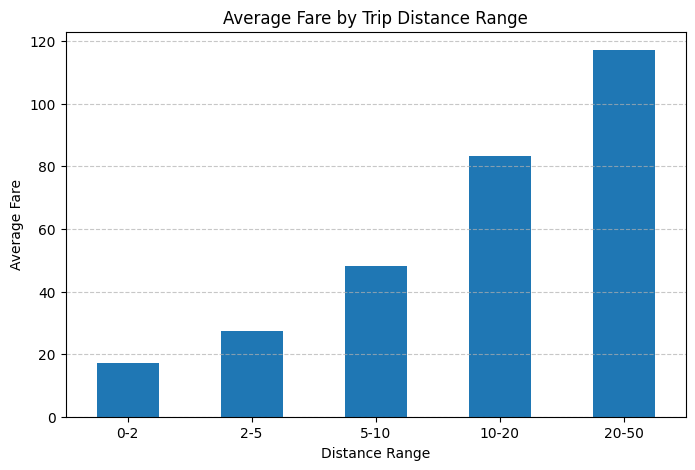

In [51]:
# Create bins for distance
train_df["distance_bins"] = pd.cut(
    train_df["trip_distance"],
    bins=[0, 2, 5, 10, 20, 50],
    labels=["0-2", "2-5", "5-10", "10-20", "20-50"]
)

# Group by bins
distance_fare = train_df.groupby("distance_bins")["total_amount"].mean()

# Plot
plt.figure(figsize=(8,5))

distance_fare.plot(kind='bar')

plt.title("Average Fare by Trip Distance Range")
plt.xlabel("Distance Range")
plt.ylabel("Average Fare")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**This Graph states that fare Increases as the distance Increases.It is exponentially increases as the distance increases.**

## Scaling and Encoding features

In [25]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        10000 non-null  object 
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             10000 non-null  object 
 6   store_and_fwd_flag     10000 non-null  object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [27]:
#Converting columns which are object type but need to be numeric
train_df["passenger_count"] = pd.to_numeric(train_df["passenger_count"], errors="coerce")
train_df["RatecodeID"] = pd.to_numeric(train_df["RatecodeID"], errors="coerce")
train_df["congestion_surcharge"] = pd.to_numeric(train_df["congestion_surcharge"], errors="coerce")
train_df["Airport_fee"] = pd.to_numeric(train_df["Airport_fee"], errors="coerce")

In [28]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        10000 non-null  float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             10000 non-null  float64
 6   store_and_fwd_flag     10000 non-null  object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

In [29]:
train_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,0.0,1.0,24.80,2.5,0.0
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,0.0,1.0,31.55,2.5,0.0
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,0.0,1.0,24.84,2.5,0.0
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,0.0,1.0,13.45,2.5,0.0
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,0.0,1.0,29.88,2.5,0.0


In [30]:
num_cols = [
    "passenger_count",
    "trip_distance",
    "congestion_surcharge",
    "Airport_fee",
    "extra",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "RatecodeID",
    "VendorID"
]

cat_cols = [
    "payment_type",
    "store_and_fwd_flag"
]

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),num_cols),
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)
    ]
)

In [32]:
y = train_df["total_amount"]
X = train_df.drop(columns=["total_amount","tpep_pickup_datetime","tpep_dropoff_datetime",])

In [33]:
from sklearn.model_selection import train_test_split
X_train,X_val, y_train, y_val = train_test_split(
    X,y,test_size=0.3, random_state =42
)

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)

## Model1 :- Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print(r2_score(y_val,y_pred))

0.8522188750778782


## Model2 :- Random Forest Regressor

In [35]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train,y_train)
y_pred2 = rfr.predict(X_val)
print(r2_score(y_val,y_pred2))

0.9276775635828418


## Model3 :- Decision Tree Regressor

In [36]:
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train,y_train)
y_pred3 = tree.predict(X_val)
print(r2_score(y_val,y_pred3))


0.852856185797089


## Model4 :- SVR

In [37]:
from sklearn.svm import SVR
svr = SVR(kernel='linear')
svr.fit(X_train,y_train)
y_pred4 = svr.predict(X_val)
print(r2_score(y_val,y_pred4))

0.8378202105797642


## Model5 :- KNeighborsRegressor

In [38]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred5 = knn.predict(X_val)
print(r2_score(y_val,y_pred5))

0.8501049364786649


## Model6 :- Ridge Regression

In [39]:
from sklearn.linear_model import Ridge
rdg = Ridge(alpha=1.0)
rdg.fit(X_train,y_train)
y_pred6 = rdg.predict(X_val)
print(r2_score(y_val,y_pred6))

0.8522129454553633


## Model7 :- AdaBoost Regressor

In [40]:
from sklearn.ensemble import AdaBoostRegressor
adb = AdaBoostRegressor(random_state=0, n_estimators=10)
adb.fit(X_train,y_train)
y_pred7 = adb.predict(X_val)
print(r2_score(y_val,y_pred7))

0.8184991780854417


## Hyper Parameter Tuning Random Forest Regressor 

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train,y_train)
y_pred2 = rfr.predict(X_val)
print("Base Model Prediction score: ",r2_score(y_val,y_pred2))

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid_search1 = GridSearchCV(
    estimator=rfr,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search1.fit(X_train,y_train)
best_rf = grid_search1.best_estimator_
y_best_pred1 = best_rf.predict(X_val)

print("Tuned Model Prediction score:", r2_score(y_val, y_best_pred1))


Base Model Prediction score:  0.9276775635828418
Tuned Model Prediction score: 0.8906611297349482


## HyperParameter Tuning SVR

In [42]:
from sklearn.svm import SVR
svr = SVR(kernel='linear')
svr.fit(X_train,y_train)
y_pred4 = svr.predict(X_val)
print("Base Model Prediction Score: ",r2_score(y_val,y_pred4))

param_grid2 = {
    "kernel": ["rbf","linear"],
    "C": [0.1,1,10,100],
    "gamma": ["scale","auto"],
    "epsilon": [0.1,0.2,0.5]
    
}
grid_search2 = GridSearchCV(
    estimator=svr,
    param_grid = param_grid2,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search2.fit(X_train, y_train)
best_svr = grid_search2.best_estimator_
y_best_pred2 = best_svr.predict(X_val)

print("Tuned Model Prediction Score: ", r2_score(y_val,y_best_pred2))


Base Model Prediction Score:  0.8378202105797642
Tuned Model Prediction Score:  0.8375046389548367


## HyperParameter Tuning KNeighborsRegressor

In [43]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred5 = knn.predict(X_val)
print("Base Model Prediction Score: ",r2_score(y_val,y_pred5))

param_grid3 = {
    "n_neighbors": [3,5,7,9,11,15],
    "weights": ["uniform","distance"],
    "p": [1,2]
}

grid_search3 = GridSearchCV(
    estimator=knn,
    param_grid= param_grid3,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search3.fit(X_train,y_train)
best_knn = grid_search3.best_estimator_
y_best_pred3 = best_knn.predict(X_val)
print("Tuned Model Prediction Score: ", r2_score(y_val,y_best_pred3))


Base Model Prediction Score:  0.8501049364786649
Tuned Model Prediction Score:  0.8674153032431864


## Comparison of Models

#### Before HyperParameter Tuning:
* **Linear Regression** -> Achieved r2 score of 0.852
* **Random Forest Regressor** -> Achieved r2 score of 0.927
* **Decision Tree Regressor** -> Achieved r2 score of 0.852
* **SVR** -> Achieved r2 score of 0.837
* **KNeighbors** -> Achieved r2 score of 0.850
* **Ridge Regression** -> Achieved r2 score of 0.852
* **Adaboost Regressor** -> Achieved r2 score of 0.818

### After HyperParameter Tuning
* **Random Forest Regressor** -> Achieved r2 score of 0.890
* **SVR** -> 0.837
* **KNeighbors** -> 0.867

**Conclusion Random Forest Regressor is the Best Model Among All with r2 score of 0.927 before Tuning.But After tuning the r2 score slightly decrease and came upto 0.890 it mights be as the model reducing the overfitting of data.**

In [44]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1500 non-null   int64  
 1   VendorID               1500 non-null   int64  
 2   tpep_pickup_datetime   1500 non-null   object 
 3   tpep_dropoff_datetime  1500 non-null   object 
 4   passenger_count        1500 non-null   object 
 5   trip_distance          1500 non-null   float64
 6   RatecodeID             1500 non-null   object 
 7   store_and_fwd_flag     1500 non-null   object 
 8   PULocationID           1500 non-null   int64  
 9   DOLocationID           1500 non-null   int64  
 10  payment_type           1500 non-null   object 
 11  extra                  1500 non-null   float64
 12  tip_amount             1500 non-null   float64
 13  tolls_amount           1500 non-null   float64
 14  improvement_surcharge  1500 non-null   float64
 15  cong

In [45]:
X_test = test_df.drop(columns=["id","tpep_pickup_datetime","tpep_dropoff_datetime"])
X_test_processed = preprocessor.transform(X_test)

In [55]:
test_pred = rfr.predict(X_test_processed)

In [54]:
test_pred

array([16.98588274, 27.24444603, 25.96626674, ..., 16.35301191,
       22.09460488, 13.28513517])

In [48]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "total_amount": test_pred
})

In [49]:
submission

,id,total_amount
0,0,18.3469
1,1,27.2688
2,2,24.7312
3,3,22.3289
4,4,12.6886
...,...,...
1495,1495,15.5982
1496,1496,9.9731
1497,1497,16.9539
1498,1498,20.7635
